# Evaluation and error analysis

With the best-performing EfficientNetB0 models saved, the next step is to evaluate performance in more detail. Rather than relying only on overall accuracy, this notebook looks at class-level behaviour, common misclassifications, and whether the correct species appears among the model’s top predictions. This helps show not just how well the model performs overall, but where it succeeds and where it struggles.

🎯 **Goal**: Evaluate the best-performing EfficientNetB0 model in detail to understand where it succeeds and where it struggles.

**Approach**:

- Load the saved fine-tuned EfficientNetB0 model
- Generate predictions on the test dataset
- Compute top-1 and top-3 accuracy
- Analyse class-level performance using precision, recall, and F1-score
- Identify worst-performing classes and top confusion pairs
- Inspect misclassified examples to understand error patterns

### Executive Summary

The model achieves 66.9% top-1 accuracy and 84.9% top-3 accuracy on the test set, indicating strong overall performance and a good understanding of the broader feature space.

Class-level analysis shows that performance is uneven, with F1-scores ranging from ~0.13 to ~0.98. Most classes perform well (F1 ~0.60–0.85), but a small subset remains challenging.

Errors are not randomly distributed, but concentrated in specific class pairs. Inspection of misclassified examples shows that some of these cases are genuinely difficult to distinguish, even on close inspection.

👉 Overall, the model performs strongly, but remaining errors are driven by a subset of difficult distinctions rather than a general failure to learn.

### Imports, data and models

In [7]:
import os
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from beakspeak.data import load_metadata, split_data, create_dataset

# --- Paths ---
DATA_DIR = Path.cwd().parent / "data"
MODEL_DIR = Path.cwd().parent / "models"

In [8]:
# Load and split the data
metadata_df = load_metadata(DATA_DIR)
train_df, val_df, test_df = split_data(metadata_df)

# Prepare labels for tf
train_df["label"] = train_df["class_id"] - 1
val_df["label"] = val_df["class_id"] - 1
test_df["label"] = test_df["class_id"] - 1

# Create train, test, val datasets
train_ds = create_dataset(train_df, shuffle=True, scaling=False)
val_ds = create_dataset(val_df, shuffle=False, scaling=False)
test_ds = create_dataset(test_df, shuffle=False, scaling=False)

In [5]:
# Load the best model
best_model = tf.keras.models.load_model(MODEL_DIR / "efficientnetb0_fine_tuned.keras")

print("✅ Model loaded successfully.")

✅ Model loaded successfully.


## Evaluation data

### Generating predictions

Running the model on the test dataset to obtain predicted probabilities for each class. 

These predictions will be used to compute metrics and analyse errors.

In [9]:
# Fetch and combine labels for evaluation (ignore images)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# Convert predictions from logits to probabilities
y_pred_raw = best_model.predict(test_ds)
y_pred_proba = tf.nn.softmax(y_pred_raw, axis=1).numpy()

# Get top-1 predicted class indices for each sample
y_pred = np.argmax(y_pred_proba, axis=1)

182/182 ━━━━━━━━━━━━━━━━━━━━ 47s 256ms/step


### Performance metrics

Computing top-1 accuracy (standard accuracy) and top-3 accuracy to assess whether the correct class appears among the model’s most likely predictions.

In [10]:
top1_accuracy = np.mean(y_pred == y_true)

top3_preds = np.argsort(y_pred_proba, axis=1)[:, -3:]

# --- Calculate top-3 accuracy ---
correct = 0

# Each sample is correct if the true label is in the top 3 predicted classes
for true, top3 in zip(y_true, top3_preds):
    if true in top3:
        correct += 1

top3_accuracy = correct / len(y_true)

print(f"Top-1 Accuracy: {top1_accuracy:.4f}")
print(f"Top-3 Accuracy: {top3_accuracy:.4f}")

Top-1 Accuracy: 0.6686
Top-3 Accuracy: 0.8490


### Classification report

Summarising precision and recall across all classes to understand how performance varies beyond overall accuracy.

In [11]:
print("\nClassification Report:")
print(classification_report(y_true, y_pred, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.77      0.67        30
           1       0.63      0.63      0.63        30
           2       0.62      0.57      0.59        28
           3       0.68      0.90      0.77        30
           4       0.79      0.79      0.79        14
           5       0.89      0.73      0.80        11
           6       0.81      0.91      0.86        23
           7       0.59      0.72      0.65        18
           8       0.37      0.24      0.29        29
           9       0.72      0.70      0.71        30
          10       0.48      0.37      0.42        30
          11       0.96      0.92      0.94        26
          12       0.72      0.87      0.79        30
          13       0.82      0.90      0.86        30
          14       0.86      0.89      0.88        28
          15       0.93      0.89      0.91        28
          16       0.82      0.85      0.84        27
   

In [14]:
report = classification_report(y_true, y_pred, output_dict=True)
df = pd.DataFrame(report).transpose()

# Remove averages
df = df.iloc[:-3]

# Sort by f1-score
df_sorted = df.sort_values("f1-score")

# Show worst + best
print("Worst classes:")
display(df_sorted.head(10))

print("\nBest classes:")
display(df_sorted.tail(10))

Worst classes:


,precision,recall,f1-score,support
61,0.200000,0.100000,0.133333,30.0
130,0.209302,0.300000,0.246575,30.0
115,0.555556,0.166667,0.256410,30.0
29,0.275862,0.266667,0.271186,30.0
8,0.368421,0.241379,0.291667,29.0
64,0.384615,0.250000,0.303030,20.0
90,0.437500,0.233333,0.304348,30.0
144,0.363636,0.266667,0.307692,30.0
178,0.285714,0.344828,0.312500,29.0
143,0.312500,0.333333,0.322581,30.0



Best classes:


,precision,recall,f1-score,support
69,0.933333,0.933333,0.933333,30.0
191,0.882353,1.000000,0.937500,30.0
11,0.960000,0.923077,0.941176,26.0
74,0.961538,0.925926,0.943396,27.0
189,0.933333,0.965517,0.949153,29.0
105,0.965517,0.933333,0.949153,30.0
187,0.965517,0.933333,0.949153,30.0
99,0.935484,0.966667,0.950820,30.0
52,1.000000,0.933333,0.965517,30.0
82,1.000000,0.966667,0.983051,30.0


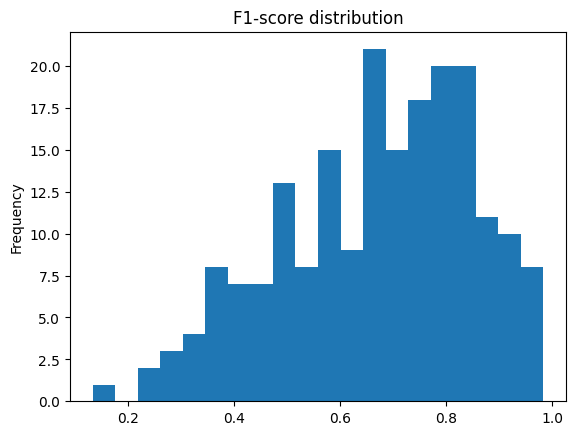

In [ ]:
# --- How evenly does the model perform across all 200 classes? ---
df_sorted["f1-score"].plot(kind="hist", bins=20, title="F1-score distribution");

🙋‍♀️ The F1-score distribution shows that performance is broadly strong across most classes, with a small subset of difficult classes driving the remaining errors.

### Confusion Matrix

Visualising how predictions are distributed across classes to identify common misclassifications.

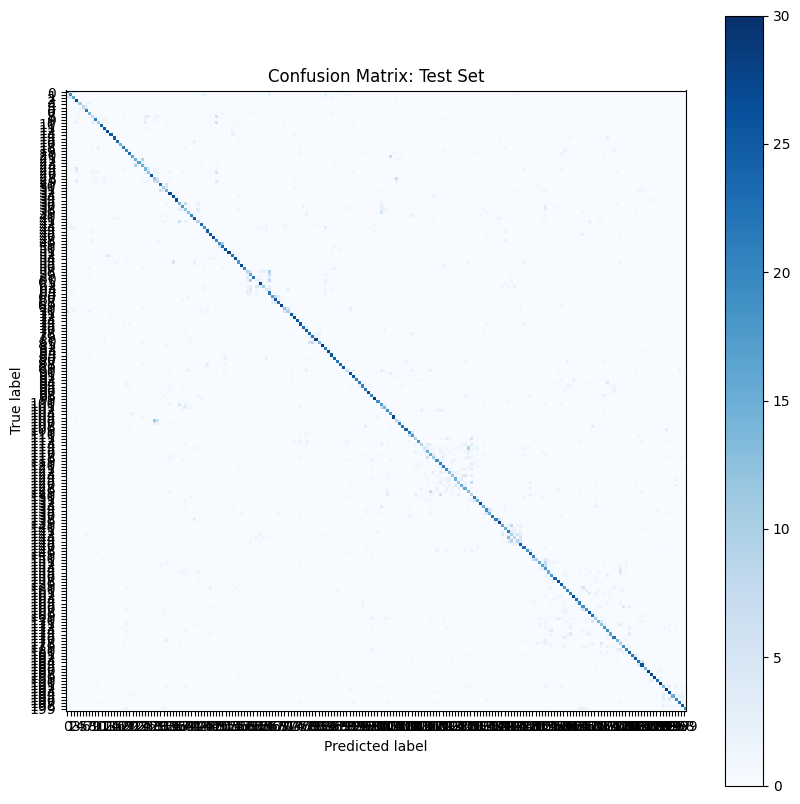

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 10))
ConfusionMatrixDisplay(cm).plot(
    include_values=False,
    cmap="Blues",
    ax=plt.gca(),
)
plt.title("Confusion Matrix: Test Set")
plt.show()

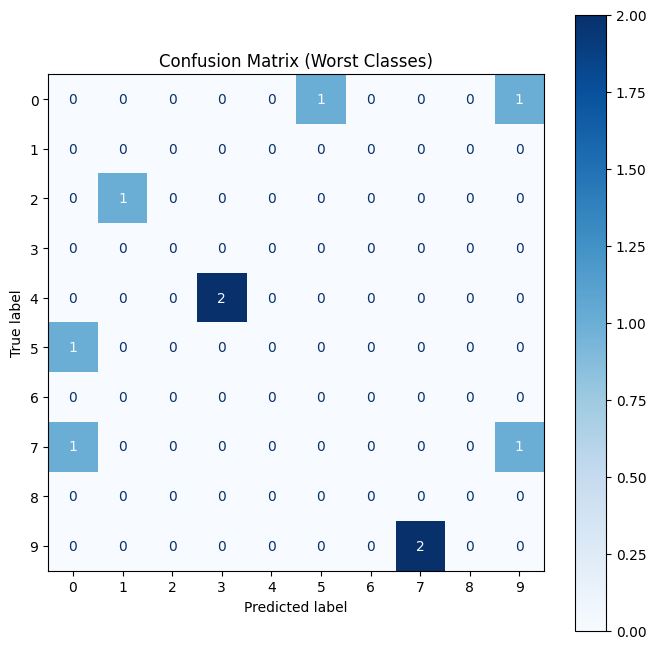

In [18]:
# --- Which classes does the model perform badly on overall?
worst_classes = df_sorted.head(10).index.astype(int)

cm_subset = cm[worst_classes][:, worst_classes]

plt.figure(figsize=(8, 8))
ConfusionMatrixDisplay(cm_subset).plot(cmap="Blues", ax=plt.gca())
plt.title("Confusion Matrix (Worst Classes)")
plt.show()

In [ ]:
# --- Which classes get mixed up the most? ---
cm = confusion_matrix(y_true, y_pred)

# zero diagonal (ignore correct preds)
np.fill_diagonal(cm, 0)

# get top confusions
top_pairs = np.dstack(np.unravel_index(np.argsort(cm.ravel())[::-1], cm.shape))[0]

top_pairs[:10]

array([[144, 142],
       [106,  28],
       [ 61,  59],
       [ 58,  65],
       [ 24,  22],
       [ 49,  50],
       [ 22,  24],
       [145, 143],
       [115, 129],
       [ 36,  38]])

### 💡 Evaluation Summary

Overall, the model achieves 66.9% top-1 accuracy and 84.9% top-3 accuracy on the test set.

This gap indicates that while the model does not always select the correct class as its top prediction, it frequently ranks the correct species among its most likely candidates.

##### Class-level performance

Performance varies meaningfully across the 200 classes, despite no class imabalnce issues:

- Most classes fall within F1 ≈ 0.60–0.85
- Strong classes reach F1 ≈ 0.93–0.98
- Weak classes drop to F1 ≈ 0.13–0.32

The **worst-performing classes** (e.g. class 61: F1 = 0.13, recall = 0.10) show consistently poor recall, suggesting the model struggles to correctly identify these species when they appear.

Several other classes fall below F1 = 0.30, confirming that a subset of species remains particularly difficult.

In contrast, the **best-performing classes** (e.g. class 82: F1 = 0.98, precision = 1.00) demonstrate both high precision and recall, indicating the model can reliably distinguish certain species.

##### Confusion patterns

Error analysis shows that misclassifications are not random but concentrated in specific class pairs, including:

```
(144 ↔ 142), (106 ↔ 28), (61 ↔ 59), (58 ↔ 65)
```

These repeated confusions indicate that the model struggles with specific class distinctions, which warrants further investigation into the underlying visual differences between these classes.

----

👉 The model has learned strong general visual representations, as reflected in its 84.9% top-3 accuracy and high performance across many classes.

However, the remaining errors are driven by a subset of difficult distinctions, with performance ranging from F1 ≈ 0.13 to 0.98 across classes.

This indicates that the primary limitation is no longer overall model capacity, but the ability to distinguish between closely related or visually similar species.



## Inspecting mistakes

Reviewing a sample of misclassified images alongside the model’s top predictions to understand where and why it fails.

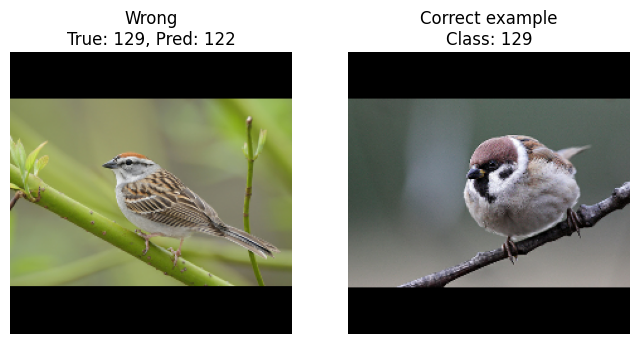

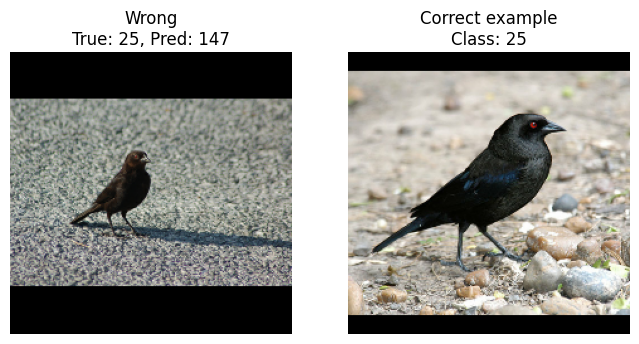

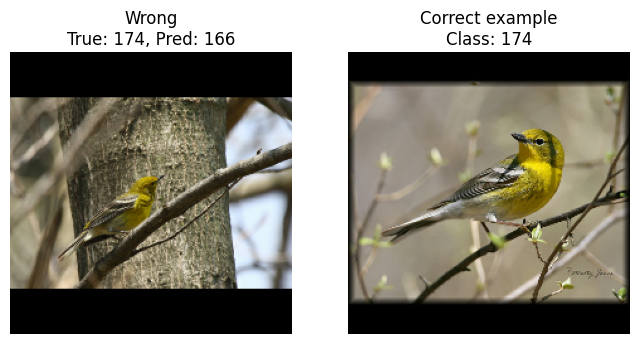

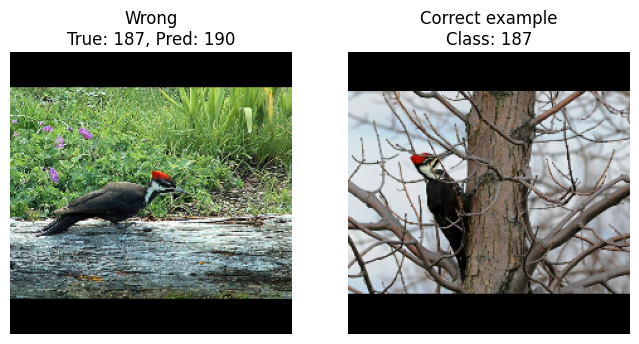

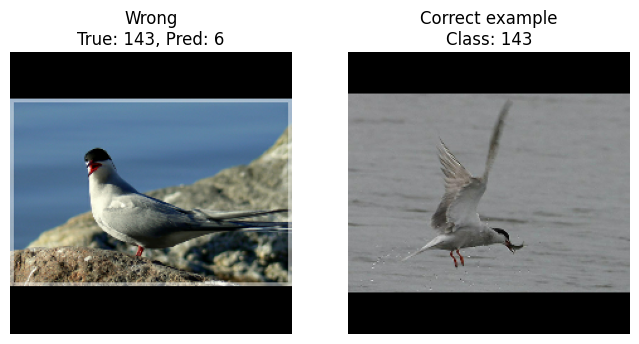

In [21]:
# Fetch and combine images for error analysis
images = np.concatenate([x.numpy() for x, _ in test_ds], axis=0)

# Get indices of misclassified samples
mistake_idx = np.where(y_true != y_pred)[0]     # np.where returns a tuple

# Show some random misclassified samples with their true and predicted labels
def show_error_with_reference(idx):
    img = images[idx]
    true_label = y_true[idx]
    pred_label = y_pred[idx]

    # find a correct example of the true class
    true_example_idx = np.where((y_true == true_label) & (y_pred == true_label))[0][0]

    true_img = images[true_example_idx]

    plt.figure(figsize=(8, 4))

    # incorrect image
    plt.subplot(1, 2, 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"Wrong\nTrue: {true_label}, Pred: {pred_label}")
    plt.axis("off")

    # correct reference
    plt.subplot(1, 2, 2)
    plt.imshow(true_img.astype("uint8"))
    plt.title(f"Correct example\nClass: {true_label}")
    plt.axis("off")

    plt.show()

# Sample a few misclassified examples to inspect
sample_idx = np.random.choice(mistake_idx, 5, replace=False)

for idx in sample_idx:
    show_error_with_reference(idx)

🙋‍♀️ Looking at some of the misclassified examples, a few are genuinely hard to tell apart even on close inspection. In those cases, the remaining errors seem to be more about how fine-grained (and sometimes ambiguous) the task is, rather than a failure of the model to learn meaningful features.

## ⭐️ Conclusion & Next Steps

This evaluation shows that the model has learned strong visual representations, with high top-3 accuracy (84.9%) indicating that it frequently identifies the correct class among its most likely predictions.

However, performance varies significantly across classes, and errors are concentrated in specific pairs. In several cases, misclassified examples are visually very similar, suggesting that the remaining challenge lies in fine-grained distinction rather than overall model capability.

Given this, further gains are unlikely to come from generic model improvements alone. Instead, the most valuable next steps are:

- **Improving how predictions are presented**: Surface top-3 predictions and confidence scores to better reflect uncertainty
- **Making outputs more interpretable**: Map class IDs to species names to support analysis and usability
- **Investigating difficult classes further**: Focus on consistently underperforming classes and their confusion patterns

👉 Overall, this shifts the focus from improving raw accuracy to better understanding and working with the model’s limitations.